# Auto-encodeur

In [2]:
import zipfile
import tempfile
import pathlib
import struct

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.stats as sp
from scipy.special import expit

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from skorch import NeuralNet

## Extraction des données

In [5]:
def charger_images_mnist(chemin_fichier):
    """Charge un fichier d'images MNIST (.idx3-ubyte) et le prépare pour l'ACP."""
    with open(chemin_fichier, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows * cols)
    return images

def charger_labels_mnist(chemin_fichier):
    """Charge un fichier d'étiquettes MNIST (.idx1-ubyte)."""
    with open(chemin_fichier, 'rb') as f:
        magic, num_items = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [6]:
chemin_donnees = "../../../../Données/mnist.zip"  # A adapter selon vos besoins
tmp = pathlib.Path(tempfile.gettempdir())
chemin_travail = tmp.joinpath("MNIST")

In [7]:
archive = zipfile.ZipFile(chemin_donnees)
archive.extractall(chemin_travail)

In [8]:
images_train = charger_images_mnist(chemin_travail.joinpath("train-images-idx3-ubyte").joinpath("train-images-idx3-ubyte"))
labels_train = charger_labels_mnist(chemin_travail.joinpath("train-labels-idx1-ubyte").joinpath("train-labels-idx1-ubyte"))
images_train.shape, labels_train.shape

((60000, 784), (60000,))

In [9]:
images_test = charger_images_mnist(chemin_travail.joinpath("t10k-images-idx3-ubyte").joinpath("t10k-images-idx3-ubyte"))
labels_test = charger_labels_mnist(chemin_travail.joinpath("t10k-labels-idx1-ubyte").joinpath("t10k-labels-idx1-ubyte"))
images_test.shape, labels_test.shape

((10000, 784), (10000,))

Normalisation des images:

In [10]:
images_train = images_train / 255.
images_test = images_test / 255.

## Fonctions de visualisation

In [11]:
def visualiser_image(images, labels, index = None, label = None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    if label is None:
        label = f"{labels[index]}"
    else:
        label = f"{label}: {labels[index]}"
    plt.imshow(image, cmap="gray", vmin=0., vmax=1.)
    plt.axis("off")
    plt.title(label)

In [12]:
def visualiser_image_classification(images, labels, scores, index=None, label=None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    if label is None:
        label = f"{labels[index]}"
    else:
        label = f"{label}: {labels[index]}"
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.imshow(image, cmap="gray", vmin=0., vmax=1.)
    ax1.axis("off")
    ax1.set_title(f"Index = {index} / Classe vraie = {label}")
    divider = make_axes_locatable(ax1)
    ax2 = divider.append_axes("right", size="100%", pad=0.5)
    probabs = scores[index]
    classe_predite = np.argmax(probabs)
    barres = ax2.barh(range(10), probabs, color="tab:blue")
    barres[classe_predite].set_color("tab:orange")
    ax2.set_yticks(range(10), range(10))
    ax2.set_xlim(0, 1.)
    ax2.set_title("probabilités")

In [13]:
def visualiser_autoencodeur(images, labels, reconstructions, index = None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    reconstruction = reconstructions[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    reconstruction = reconstruction.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    label = f"{labels[index]}"
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image, cmap="gray", vmin=0., vmax=1.)
    axes[1].imshow(reconstruction, cmap="gray", vmin=0., vmax=1.)
    axes[0].axis("off")
    axes[0].set_title(f"Index = {index} / Classe vraie = {label}")
    axes[1].axis("off")
    axes[1].set_title(f"Index = {index} / Classe vraie = {label}")    

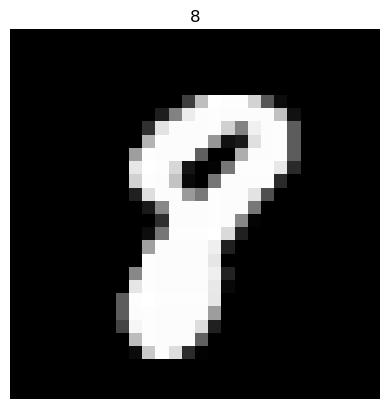

In [14]:
visualiser_image(images_train, labels_train)

## Préparation des données

In [16]:
X_train = images_train.astype(np.float32)
X_test = images_test.astype(np.float32)

## Entrainement de l'auto-encodeur

In [17]:
encoder = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 16)
)

In [18]:
decoder = nn.Sequential(
    nn.Linear(16, 64),
    nn.ReLU(),
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, 784),
    # nn.Sigmoid()
)

In [19]:
model = nn.Sequential(
    encoder,
    decoder
)

In [20]:
def init_weights_kaiming(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)
model.apply(init_weights_kaiming);
nn.init.xavier_normal_(model[1][4].weight);

In [21]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(dataset, batch_size=256, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [22]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [25]:
def fit_model(model, train_loader, optimizer, criterion, epochs=100):
    model.train()
    # Boucle sur le epochs
    for epoch in range(epochs):
        running_loss = 0.0
        
        # Itération sur tous les mini-batchs du DataLoader
        for batch_inputs, batch_targets in train_loader:
            # Envoi des batchs sur le CPU ou le GPU
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)
            
            # On vide les gradients accumulés à l'étape précédente
            optimizer.zero_grad()
            
            # Passe avant
            batch_outputs = model(batch_inputs)
            
            # Calcul de la perte sur le batch courant
            loss = criterion(batch_outputs, batch_targets)
            
            # Passe arrière (Rétro-propagation du gradient)
            loss.backward()
            
            # Mise à jour des poids et des biais par l'optimiseur Adam
            optimizer.step()
            
            # Accumulation de la perte pondérée par la taille du batch
            running_loss += loss.item() * batch_inputs.size(0)
            
        # Calcul de la perte moyenne sur l'ensemble de l'époque
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Affichage de la progression toutes les 10 époques
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Époque [{epoch+1}/{epochs}] - Perte moyenne : {epoch_loss:.4f}")

In [26]:
fit_model(model, train_loader, optimizer, criterion, epochs=100)

Époque [1/100] - Perte moyenne : 0.1327
Époque [10/100] - Perte moyenne : 0.1057
Époque [20/100] - Perte moyenne : 0.0997
Époque [30/100] - Perte moyenne : 0.0968
Époque [40/100] - Perte moyenne : 0.0951
Époque [50/100] - Perte moyenne : 0.0939
Époque [60/100] - Perte moyenne : 0.0930
Époque [70/100] - Perte moyenne : 0.0924
Époque [80/100] - Perte moyenne : 0.0918
Époque [90/100] - Perte moyenne : 0.0913
Époque [100/100] - Perte moyenne : 0.0909


In [27]:
model_inference = nn.Sequential(model, nn.Sigmoid())

In [28]:
model_inference.eval()  # On passe le modèle en mode évaluation
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():  # Désactive le calcul des gradients
    X_reconstructed = model_inference(X_test_tensor).cpu().numpy()

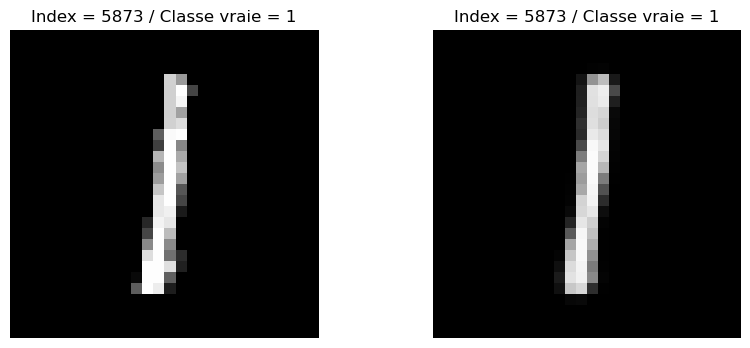

In [29]:
visualiser_autoencodeur(images_test, labels_test, X_reconstructed)

## Auto-encoder variationnel

In [372]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Le même encodeur que précédemment à l'exception de la dernière couche linéaire
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),            
            nn.Linear(128, 64),
            nn.ReLU()
        )
        # Cette dernière couche linéaire est remplacée par 2 couches qui vont fonctionner en parallèle (une bifurcation)
        # La première est pour la moyenne sur l'espace latent
        # La seconde est pour la variance sur l'espace latent
        self.mu = nn.Linear(64, 32)
        self.logvar = nn.Linear(64, 32)  # c'est en fait le logarithme de la variance, parce que c'est plus stable.

        # On finit par le même décodeur qu'avant
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            # nn.Sigmoid()
        )        

    def reparametrize(self, mu, logvar):
        # Ici on vient échantilloner 1 point de la distribution que l'on essaie de construire, c'est ce que 
        # l'on passera ensuite au décodeur
        std = torch.exp(0.5 * logvar)  # std = sqrt(exp(logvar))
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Passage par l'encodeur
        h = self.encoder(x)
        # Gestion de l'espace latent
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparametrize(mu, logvar)
        # Reconstruction avec le décodeur
        reconstructed = self.decoder(z)
        # Reconstructed servira pour l'erreur quadratique moyenne de construction
        # mu et logvar serviront pour calculer une pénalité liée à la divergence KL
        return reconstructed, mu, logvar

In [379]:
class BCEKLLoss(nn.Module): 
    def __init__(self, beta=1):
        super().__init__()
        self.beta = beta
    
    def forward(self, outputs, targets):
        # On récupère la sortie de l'auto-encodeur variationnel
        reconstructed, mu, logvar = outputs
        # On calcule l'erreur quandratique moyenne
        bce = F.binary_cross_entropy_with_logits(reconstructed, targets, reduction='sum')
        # On calcule la divergence KL
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        # La perte totale est la somme des deux
        return bce + self.beta * kl

In [380]:
class AutoEncoderSigmoid(nn.Module):
    def forward(self, x):
        reconstructed, mu, logvar = x
        return F.sigmoid(reconstructed)

In [387]:
model = VariationalAutoEncoder()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [1]:
def init_weights_kaiming(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)
model.apply(init_weights_kaiming);
nn.init.xavier_normal_(model.decoder[6].weight);

NameError: name 'model' is not defined

In [394]:
total_epochs = 0
while total_epochs < 100:
    if total_epochs < 10:
        beta = 0.
    elif total_epochs < 50:
        beta = (total_epochs - 10) / 40
    else:
        beta = 1.
    print("Beta = ", beta)
    criterion = BCEKLLoss(beta=beta)
    fit_model(model, train_loader, optimizer, criterion, epochs=10)
    total_epochs += 10

Époque [1/100] - Perte moyenne : 40024.9873
Époque [10/100] - Perte moyenne : 18962.3549
Époque [1/100] - Perte moyenne : 18744.9170
Époque [10/100] - Perte moyenne : 17517.0639
Époque [1/100] - Perte moyenne : 26015.1366
Époque [10/100] - Perte moyenne : 21808.2558
Époque [1/100] - Perte moyenne : 24892.2887
Époque [10/100] - Perte moyenne : 23467.7702
Époque [1/100] - Perte moyenne : 25617.5028
Époque [10/100] - Perte moyenne : 24903.9472
Époque [1/100] - Perte moyenne : 26717.4417
Époque [10/100] - Perte moyenne : 26379.3618
Époque [1/100] - Perte moyenne : 26353.2924
Époque [10/100] - Perte moyenne : 26150.5291
Époque [1/100] - Perte moyenne : 26117.2068
Époque [10/100] - Perte moyenne : 25966.7825
Époque [1/100] - Perte moyenne : 25953.2662
Époque [10/100] - Perte moyenne : 25806.0669
Époque [1/100] - Perte moyenne : 25793.1690
Époque [10/100] - Perte moyenne : 25696.3476


In [395]:
model_inference = nn.Sequential(model, AutoEncoderSigmoid())

In [396]:
model_inference.eval()  # On passe le modèle en mode évaluation
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():  # Désactive le calcul des gradients
    X_reconstructed = model_inference(X_test_tensor).cpu().numpy()

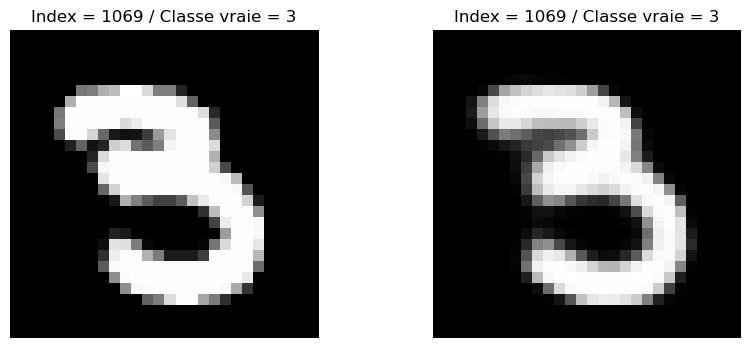

In [405]:
visualiser_autoencodeur(images_test, labels_test, X_reconstructed)

In [406]:
decoder = nn.Sequential(model.decoder, nn.Sigmoid())
decoder

Sequential(
  (0): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=784, bias=True)
  )
  (1): Sigmoid()
)

In [407]:
norm = sp.multivariate_normal(np.zeros(32), np.eye(32))

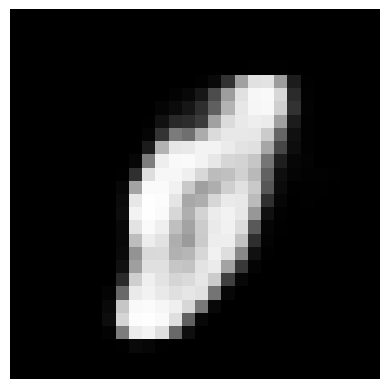

In [424]:
with torch.no_grad():
    decoder.eval()
    sample = torch.as_tensor(norm.rvs(1).astype(np.float32))
    image = decoder(sample)
plt.imshow(image.numpy().reshape((28, 28)), cmap="gray", vmin=0., vmax=1.)
plt.axis("off");

In [204]:
class AutoEncoderNet(NeuralNet):
    def predict(self, X):
        # Calcul les logits
        logits = super().predict(X)
        # return logits
        # On applique et retourne la sigmoïde automatiquement
        print("POUEEEEEEEEEEEEEET")
        return expit(logits)

In [205]:
net = AutoEncoderNet(
    model,
    max_epochs=1,  # Il faudra 50 epochs pour avoir un bon résultat (0.130 de test loss)
    lr=0.001,
    optimizer=torch.optim.Adam,
    # criterion=nn.MSELoss,
    # criterion=nn.BCELoss,
    criterion=nn.BCEWithLogitsLoss,
    iterator_train__batch_size=256,
    device='cpu'
)

In [206]:
net.fit(X_train, X_train);

  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        0.2377        0.1640  1.6690


In [193]:
# net.partial_fit(X_train, X_train);

In [207]:
Y_hat = net.predict(X_test)[:, 1, :]
Y_hat[0]

POUEEEEEEEEEEEEEET


array([0.50000006, 0.50000006, 0.5       , 0.50000006, 0.50000066,
       0.5000081 , 0.50000024, 0.50000095, 0.5000002 , 0.5000001 ,
       0.50000024, 0.5000014 , 0.5000002 , 0.5000002 , 0.50000006,
       0.5000008 , 0.50000006, 0.5000003 , 0.50000006, 0.50000006,
       0.50000155, 0.5       , 0.5000002 , 0.5000001 , 0.5000002 ,
       0.5       , 0.50000006, 0.5       , 0.5000001 , 0.5       ,
       0.50000006, 0.5       , 0.5000016 , 0.5000007 , 0.50000006,
       0.5000005 , 0.5000005 , 0.50000036, 0.5000122 , 0.50007206,
       0.5000002 , 0.50001884, 0.50000113, 0.5000025 , 0.5000252 ,
       0.5000393 , 0.50000286, 0.5000001 , 0.5000017 , 0.50000006,
       0.50000006, 0.5       , 0.5000007 , 0.5       , 0.5000006 ,
       0.5000002 , 0.50000006, 0.50000006, 0.50000006, 0.5000001 ,
       0.5000002 , 0.5000002 , 0.5000001 , 0.5000002 , 0.50001824,
       0.5000099 , 0.5000122 , 0.50001025, 0.5000195 , 0.50001085,
       0.5000033 , 0.5000015 , 0.50000036, 0.50000024, 0.50000

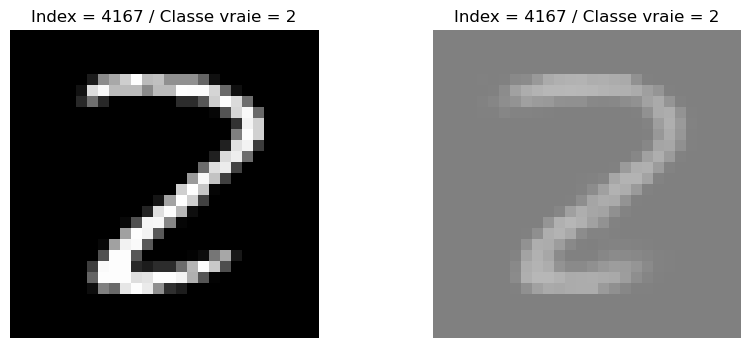

In [195]:
visualiser_autoencodeur(images_test, labels_test, Y_hat)

## Auto-encodeur variationnel

In [1120]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Le même encodeur que précédemment à l'exception de la dernière couche linéaire
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),            
            nn.Linear(128, 64),
            nn.ReLU()
        )
        # Cette dernière couche linéaire est remplacée par 2 couches qui vont fonctionner en parallèle (une bifurcation)
        # La première est pour la moyenne sur l'espace latent
        # La seconde est pour la variance sur l'espace latent
        self.mu = nn.Linear(64, 32)
        self.logvar = nn.Linear(64, 32)  # c'est en fait le logarithme de la variance, parce que c'est plus stable.

        # On finit par le même décodeur qu'avant
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )        

    def reparametrize(self, mu, logvar):
        # Ici on vient échantilloner 1 point de la distribution que l'on essaie de construire, c'est ce que 
        # l'on passera ensuite au décodeur
        std = torch.exp(0.5 * logvar)  # std = sqrt(exp(logvar))
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Passage par l'encodeur
        h = self.encoder(x)
        # Gestion de l'espace latent
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparametrize(mu, logvar)
        # Reconstruction avec le décodeur
        reconstructed = self.decoder(z)
        # Reconstructed servira pour l'erreur quadratique moyenne de construction
        # mu et logvar serviront pour calculer une pénalité liée à la divergence KL
        return reconstructed, mu, logvar

In [1166]:
class MSEKLLoss(nn.Module):    
    def forward(self, outputs, targets):
        # On récupère la sortie de l'auto-encodeur variationnel
        reconstructed, mu, logvar = outputs
        # On calcule l'erreur quandratique moyenne
        mse = F.mse_loss(reconstructed, targets, reduction='sum')
        # On calcule la divergence KL
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        # La perte totale est la somme des deux
        return mse + 0.1 * kl

In [1167]:
net = NeuralNetRegressor(
    VariationalAutoEncoder,
    max_epochs=50,  # Il faudra 50 epochs pour avoir un bon résultat (0.130 de test loss)
    lr=0.01,
    optimizer=torch.optim.Adam,
    criterion=MSEKLLoss,
    iterator_train__batch_size=256,
    device='cpu',
)

In [1168]:
net.fit(X_train, X_train);

  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1    12718.3231     5581.9813  2.3135
      2    10008.1987     4615.0965  2.3336
      3     8743.9447     4803.0916  2.3225
      4     8107.0503     4005.0871  2.3030
      5     7751.5619     3922.9529  2.3381
      6     7593.6289     3831.9667  2.3142
      7     7446.6967     3740.5709  2.3606
      8     7362.4845     3670.3362  2.3363
      9     7269.7780     3605.8263  2.3413
     10     7223.8617     3653.3259  2.3453
     11     7178.0626     3791.3639  2.3585
     12     7151.3045     3773.9725  2.5450
     13     7125.3951     3591.7354  2.3530
     14     7079.1736     3595.3843  2.3225
     15     7040.8796     3531.3123  2.3703
     16     7022.2218     3502.9235  2.3553
     17     7001.4873     3532.3923  2.2961
     18     6994.1556     3524.9342  2.3076
     19     6978.6720     3582.0686  2.3343
     20     6970.5309     3502.0233  2.3433
     21     6966.0045     3588.2

In [1218]:
net.partial_fit(X_train, X_train);

     51     6852.1282     3419.7384  3.0500
     52     6866.3882     3449.3796  2.5633
     53     6852.6344     3432.7176  2.3047
     54     6856.1851     3503.6492  3.0855
     55     6876.3564     3464.8188  3.0819
     56     6836.0320     3400.9706  2.6342
     57     6845.6741     3480.4007  2.3289
     58     6841.0794     3423.9216  2.4522
     59     6864.0349     3417.4107  2.5760
     60     6845.0981     3392.8247  2.4231
     61     6805.7764     3407.9779  2.4008
     62     6822.0585     3432.9697  2.4559
     63     6844.3833     3398.1736  2.3998


Meilleurs réglages: 32 dimensions latentes, beta 0.1 (100 epochs)

In [1250]:
with torch.no_grad():
    Y_hat, mu, logvar = net.module_.forward(torch.Tensor(X_test))

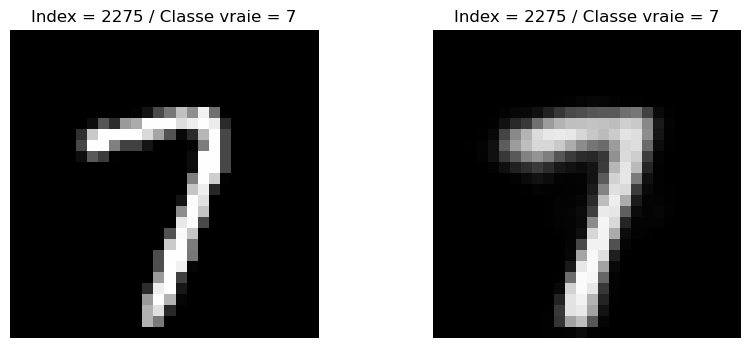

In [1251]:
visualiser_autoencodeur(images_test, labels_test, Y_hat.numpy())

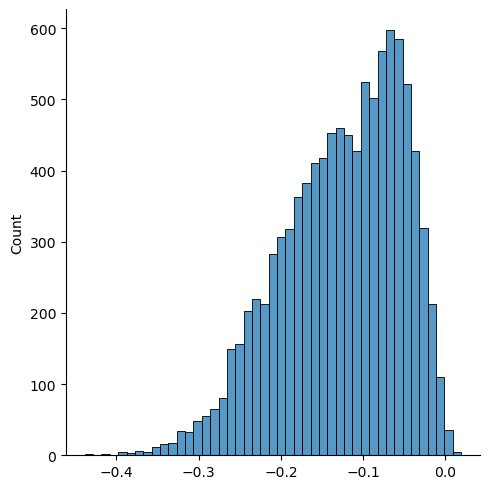

In [1209]:
sns.displot(mu[:,0])

In [1210]:
#net.save_params(f_params='./modèles/vae_model.pkl', f_optimizer='./modèles/vae_opt.pkl', f_history='./modèles/vae_history.json')

In [1219]:
net.initialize()
net.load_params(f_params='./modèles/vae_model.pkl', f_optimizer='./modèles/vae_opt.pkl', f_history='./modèles/vae_history.json')

Re-initializing module.
Re-initializing criterion.
Re-initializing optimizer.


## IA Générative

In [1252]:
decoder = net.module_.decoder
decoder

Sequential(
  (0): Linear(in_features=32, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=784, bias=True)
  (7): Sigmoid()
)

In [1253]:
norm = sp.multivariate_normal(np.zeros(32), np.eye(32))

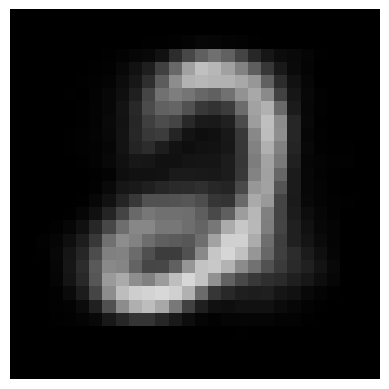

In [1297]:
with torch.no_grad():
    decoder.eval()
    sample = torch.as_tensor(norm.rvs(1).astype(np.float32))
    # sample = torch.as_tensor(np.zeros((1, 32)).astype(np.float32))
    image = decoder(sample)
plt.imshow(image.numpy().reshape((28, 28)), cmap="gray", vmin=0., vmax=1.)
plt.axis("off");

In [761]:
print(sample)

tensor([ 1.1233, -0.9304, -0.0412,  1.4360, -1.2571, -0.8021,  0.5276, -1.8145,
         0.6747,  1.2823,  1.6820,  0.7081, -1.3027, -0.1220,  0.3897,  0.8548,
         0.0065,  0.3241,  2.2115, -0.0958,  1.4890, -1.1335,  0.9397,  0.3311,
        -1.7255,  0.0050,  2.0358,  0.6646, -0.6715, -1.1968, -0.2133, -0.9402])


## Maximisation de l'activation

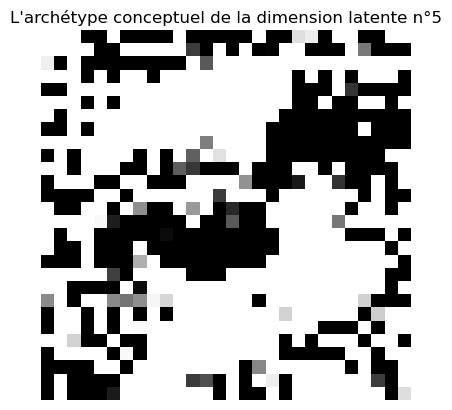

In [830]:
# 1. On définit une fonction qui fait le chemin : Image -> Encoder -> Mu
def get_latent_activation(image_tensor, model, target_dim):
    h = model.encoder(image_tensor)
    mu = model.mu(h)
    return mu[0, target_dim] # On cible la dimension choisie

# 2. La boucle d'optimisation (sur l'image d'entrée)
input_image = torch.randn((1, 784), requires_grad=True)
optimizer = torch.optim.Adam([input_image], lr=0.01, maximize=True)

model_vae = net.module_
model_vae.eval()
target_dim = 5

for i in range(500):
    optimizer.zero_grad()
    
    # On veut maximiser la valeur de mu pour la dimension X
    score = get_latent_activation(input_image, model_vae, target_dim=target_dim)
    # print(score)
    
    # Maximisation = Minimiser l'opposé
    score.backward()
    optimizer.step()
    
    # Contrainte pour rester dans le monde des images (0-1)
    input_image.data.clamp_(0, 1)

final_image = input_image.detach().numpy().reshape(28, 28)
plt.imshow(final_image, cmap='gray')
plt.title(f"L'archétype conceptuel de la dimension latente n°{target_dim}")
plt.axis('off');

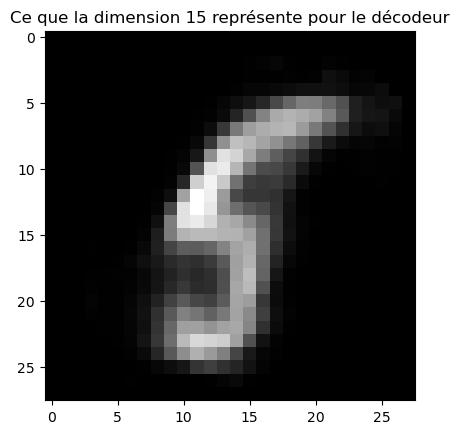

In [893]:
z = torch.zeros((1, 32))
# z = torch.randn((1, 32))
z[0, 0] = 6.  # On force la dimension 15 à une forte valeur positive  (dim: 19, 13, 5)

with torch.no_grad():
    archetype_visuel = model_vae.decoder(z)

plt.imshow(archetype_visuel.numpy().reshape(28, 28), cmap='gray')
plt.title("Ce que la dimension 15 représente pour le décodeur");

On prend l'encoder, mais on veut figer ses paramètres:

In [220]:
encoder = net.module_[0]
encoder

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=16, bias=True)
)

In [221]:
encoder.eval()
for param in encoder.parameters():
    param.requires_grad = False

Maximisation de la dimension latente n°5...
  Itération 0/500, Score : -4.2907
  Itération 100/500, Score : 23.0454
  Itération 200/500, Score : 26.6213
  Itération 300/500, Score : 27.5381
  Itération 400/500, Score : 27.7794


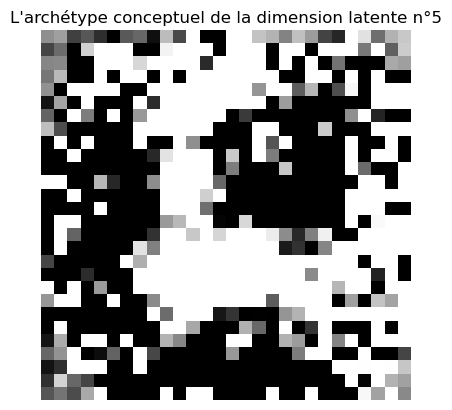

In [236]:
# On cible la première dimension (indice 0) sur les 16
target_dim = 5
n_iterations = 500
learning_rate = 0.1 # Plus agressif que pour l'entraînement

# 1. On crée une image "caractère d'entrée" (grise au hasard)
# requires_grad=True est LA commande clé : on va dériver par rapport à l'image !
# input_image = torch.randn((1, 784), requires_grad=True)
base = torch.ones((1, 784)) * 0.5
noise = torch.randn((1, 784)) * 0.01
input_image = (base + noise).requires_grad_()

# 2. On utilise l'optimiseur pour modifier l'image (pas les poids !)
# Remarque : SGD classique suffit pour modifier 784 pixels
optimizer = torch.optim.SGD([input_image], lr=learning_rate, maximize=True)

print(f"Maximisation de la dimension latente n°{target_dim}...")
for i in range(n_iterations):
    optimizer.zero_grad()
    
    # Passe avant dans l'encodeur
    latent_space = encoder(input_image)
    
    # Le score : la valeur de la dimension cible
    score = latent_space[0, target_dim]
    
    # Rétro-propagation vers L'IMAGE
    score.backward()
    
    # L'optimiseur modifie les pixels
    optimizer.step()
    
    # Astuce de live coding : On force l'image à rester entre 0 et 1 (clipping)
    # pour que le résultat ressemble à un vrai pixel MNIST
    with torch.no_grad():
        input_image.clamp_(0, 1)
        
    if i % 100 == 0:
        print(f"  Itération {i}/{n_iterations}, Score : {score.item():.4f}")

# 3. Visualisation du résultat
final_image = input_image.detach().numpy().reshape(28, 28)
plt.imshow(final_image, cmap='gray')
plt.title(f"L'archétype conceptuel de la dimension latente n°{target_dim}")
plt.axis('off')
plt.show()